# F1_Definicion.ipynb — Fase 1: Definición y orientación de la situación

**Curso:** MCDI504 – Machine Learning I
**Caso:** Certificación de lotes de flor cortada mediante un clasificador con opción de rechazo
**Grupo:** GRUPO 7

Este cuaderno acompaña al informe de la Fase 1. No busca entrenar un modelo definitivo, sino dejar
constancia ejecutable de las decisiones que sostienen el enfoque metodológico: el origen y estado de
los datos, dónde se concentra la incertidumbre del problema y qué evidencia justifica incorporar una
opción de rechazo al esquema de clasificación.

El flujo respeta la secuencia del apunte de Fase 1 del curso (Ruete, 2026c): carga, inspección,
descripción, visualización, codificación de la variable de decisión, correlación, normalización y
significancia. Los nombres de los objetos (`bbdd1`, `bbdd2`, `bbdd_norm_completa`) se conservan
deliberadamente para mantener trazabilidad con el material docente.

## 1. Definición del problema y objetivos

**Contexto.** Una unidad de control de calidad certifica lotes de flor cortada según la especie
declarada por el productor. La verificación se apoya en cuatro mediciones morfométricas que el
personal de recepción registra sobre una muestra del lote.

**Situación que origina el análisis.** El costo de certificar mal es alto. *Setosa* se separa sin
ambigüedad del resto, pero los errores se concentran en el par *Versicolor* / *Virginica*, cuyas
medidas de pétalo se solapan. Forzar una etiqueta en esa zona dudosa arriesga certificaciones
incorrectas: un clasificador convencional siempre responde, incluso cuando la evidencia no alcanza.

**Pregunta analítica.** ¿Permiten las cuatro mediciones morfométricas fundamentar un certificador
con opción de rechazo que etiquete automáticamente los lotes separables y derive a revisión humana
la zona de solapamiento, y qué umbral de abstención minimiza el costo esperado de error?

**Objetivo general.** Definir y justificar el enfoque metodológico inicial de un proyecto de
clasificación supervisada con opción de rechazo para la certificación de lotes, estableciendo dónde
se concentra la incertidumbre del problema y cómo se traduce en una regla de derivación a revisión
humana, en el marco del proceso KDD.

**Objetivos específicos.**

1. Caracterizar la estructura del conjunto de datos: unidad de análisis, variables de entrada,
   variable de decisión, completitud y balance de clases.
2. Identificar dónde se concentra la incertidumbre del problema, contrastando la separabilidad de
   *Setosa* con el solapamiento del par *Versicolor* / *Virginica*.
3. Evaluar la asociación lineal entre las variables mediante correlación de Pearson y su
   significancia, identificando redundancia entre predictores.
4. Normalizar las variables de entrada al rango [0, 1] para habilitar algoritmos sensibles a la
   escala.
5. Verificar la viabilidad del certificador con opción de rechazo mediante la curva de cobertura
   frente a exactitud selectiva, y determinar el umbral que minimiza el costo esperado.
6. Contrastar el enfoque con las alternativas metodológicas disponibles y justificar su descarte.

**Alcance.** Esta fase cierra en la preparación de datos y en la verificación de factibilidad del
mecanismo de abstención. No incluye calibración de probabilidades ni comparación formal de
algoritmos, que corresponden a las fases siguientes.

## 2. Preparación del entorno

Se declaran explícitamente las instalaciones aunque el entorno ya disponga de las librerías, de modo
que el cuaderno pueda reejecutarse en Google Colab o en una máquina limpia sin pasos adicionales.

In [1]:
# Instalación de paquetes necesarios
# En Google Colab o Jupyter Notebook:
# !pip install pandas numpy seaborn matplotlib scikit-learn scipy

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.pipeline import make_pipeline
from scipy.stats import pearsonr

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

FIG = Path("../figures"); OUT = Path("../outputs")
FIG.mkdir(exist_ok=True); OUT.mkdir(exist_ok=True)

AZUL, ROJO = "#1F3A5F", "#B22222"

## 3. Selección de datos (etapa 1 del proceso KDD)

La fuente primaria es el archivo `data/iris.csv` entregado en la plataforma del curso, no la copia
embebida en `scikit-learn`. La razón es de trazabilidad: el archivo queda versionado en el
repositorio y cualquier persona que reejecute el cuaderno trabaja sobre el mismo insumo. De todos
modos se contrasta contra `load_iris()` para descartar que la copia local esté alterada.

In [3]:
RUTA = Path("../data/iris.csv")
COLUMNAS = ["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]

if RUTA.exists():
    bbdd1 = pd.read_csv(RUTA)
    origen = "archivo local data/iris.csv"
else:  # respaldo si el cuaderno se ejecuta fuera del repositorio
    iris = load_iris()
    bbdd1 = pd.DataFrame(iris.data, columns=COLUMNAS)
    bbdd1["variety"] = pd.Categorical.from_codes(iris.target, iris.target_names)
    origen = "scikit-learn (respaldo)"

bbdd1.columns = COLUMNAS + ["Species"]
bbdd1["Species"] = pd.Categorical(bbdd1["Species"],
                                  categories=["Setosa", "Versicolor", "Virginica"])

print("Origen de los datos:", origen)
print("Dimensiones:", bbdd1.shape)
bbdd1.head()

Origen de los datos: archivo local data/iris.csv
Dimensiones: (150, 5)


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
referencia = load_iris()
coincide = np.allclose(bbdd1[COLUMNAS].values, referencia.data)
print("¿El archivo local coincide con load_iris()?", coincide)

¿El archivo local coincide con load_iris()? True


## 4. Preprocesamiento: estructura, completitud y balance (etapa 2 del proceso KDD)

Interesan tres cosas antes de describir las variables: los tipos de dato asignados, la presencia de
valores faltantes y el balance de la variable de decisión, porque un desbalance marcado condicionaría
tanto la elección del algoritmo como la métrica de evaluación.

In [5]:
print("Estructura de la base de datos:")
bbdd1.info()

print("\nValores faltantes por columna:")
print(bbdd1.isna().sum())

print("\nRegistros duplicados:", bbdd1.duplicated().sum())

print("\nBalance de la variable de decisión:")
print(bbdd1["Species"].value_counts())

Estructura de la base de datos:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal.Length  150 non-null    float64 
 1   Sepal.Width   150 non-null    float64 
 2   Petal.Length  150 non-null    float64 
 3   Petal.Width   150 non-null    float64 
 4   Species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB

Valores faltantes por columna:
Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
dtype: int64

Registros duplicados: 1

Balance de la variable de decisión:
Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [6]:
# Los duplicados no se eliminan: se inspeccionan antes de decidir
bbdd1[bbdd1.duplicated(keep=False)]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
101,5.8,2.7,5.1,1.9,Virginica
142,5.8,2.7,5.1,1.9,Virginica


El registro duplicado corresponde a dos lotes cuyas cuatro mediciones coinciden tras el
redondeo a un decimal. No hay evidencia de error de digitación y con esa granularidad la coincidencia
es esperable, de modo que se conserva. La decisión queda documentada en el informe.

## 5. Estadística descriptiva

In [7]:
print("Resumen estadístico:")
print(bbdd1.describe(include="all"))

Resumen estadístico:
        Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
count     150.000000   150.000000    150.000000   150.000000     150
unique           NaN          NaN           NaN          NaN       3
top              NaN          NaN           NaN          NaN  Setosa
freq             NaN          NaN           NaN          NaN      50
mean        5.843333     3.057333      3.758000     1.199333     NaN
std         0.828066     0.435866      1.765298     0.762238     NaN
min         4.300000     2.000000      1.000000     0.100000     NaN
25%         5.100000     2.800000      1.600000     0.300000     NaN
50%         5.800000     3.000000      4.350000     1.300000     NaN
75%         6.400000     3.300000      5.100000     1.800000     NaN
max         7.900000     4.400000      6.900000     2.500000     NaN


In [8]:
resumen = bbdd1[COLUMNAS].describe().T[["mean", "std", "min", "50%", "max"]]
resumen["cv"] = bbdd1[COLUMNAS].std() / bbdd1[COLUMNAS].mean()
resumen = resumen.round(3)
resumen.to_csv(OUT / "resumen_estadistico.csv")
resumen

,mean,std,min,50%,max,cv
Sepal.Length,5.843,0.828,4.3,5.80,7.9,0.142
Sepal.Width,3.057,0.436,2.0,3.00,4.4,0.143
Petal.Length,3.758,1.765,1.0,4.35,6.9,0.470
Petal.Width,1.199,0.762,0.1,1.30,2.5,0.636


In [9]:
descriptivo_especie = bbdd1.groupby("Species", observed=True)[COLUMNAS].agg(["mean", "std"]).round(3)
descriptivo_especie.to_csv(OUT / "descriptivo_por_especie.csv")
descriptivo_especie

Sepal.Length        Sepal.Width        Petal.Length        Petal.Width       
                   mean    std        mean    std         mean    std        mean    std
Species                                                                                 
Setosa            5.006  0.352       3.428  0.379        1.462  0.174       0.246  0.105
Versicolor        5.936  0.516       2.770  0.314        4.260  0.470       1.326  0.198
Virginica         6.588  0.636       2.974  0.322        5.552  0.552       2.026  0.275

## 6. Visualización inicial

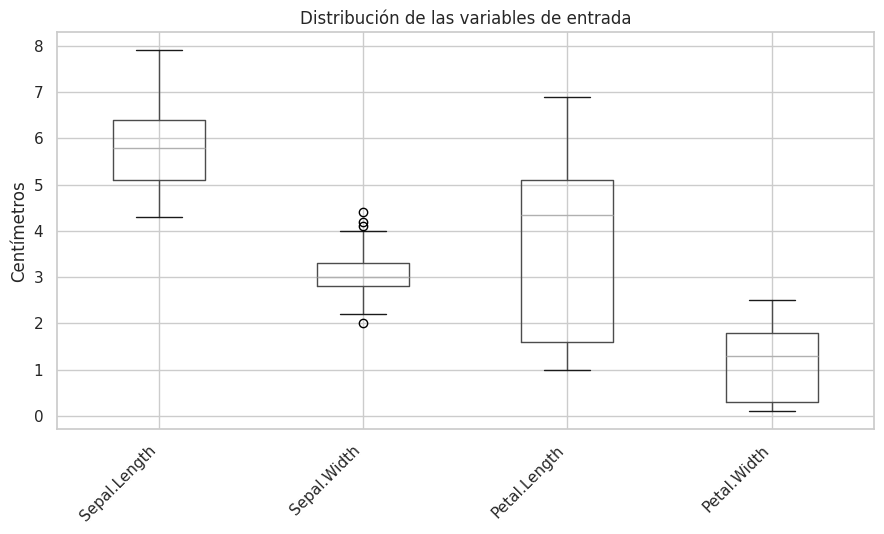

In [10]:
plt.figure(figsize=(9, 5.5))
bbdd1.iloc[:, 0:4].boxplot()
plt.xticks(rotation=45, ha="right")
plt.ylabel("Centímetros")
plt.title("Distribución de las variables de entrada")
plt.tight_layout()
plt.savefig(FIG / "boxplot_entradas.png", dpi=160)
plt.show()

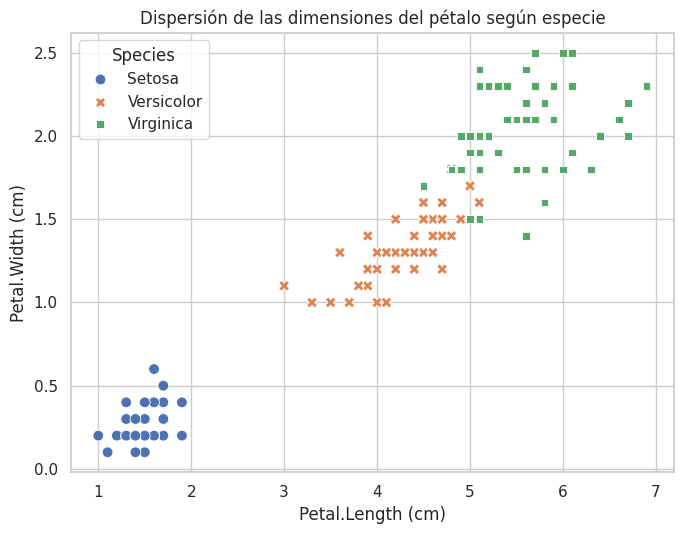

In [11]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=bbdd1, x="Petal.Length", y="Petal.Width",
                hue="Species", style="Species", s=60, palette="deep")
plt.title("Dispersión de las dimensiones del pétalo según especie")
plt.xlabel("Petal.Length (cm)"); plt.ylabel("Petal.Width (cm)")
plt.tight_layout()
plt.savefig(FIG / "dispersion_petalo.png", dpi=160)
plt.show()

## 7. Dónde se concentra la incertidumbre

Este apartado justifica por qué el problema requiere una opción de rechazo. Si la dificultad
estuviera repartida de forma pareja entre las tres clases, un umbral de abstención derivaría lotes
de todas ellas y su utilidad sería discutible. Lo que sigue verifica si ese es el caso.

In [12]:
maximo_setosa = bbdd1.loc[bbdd1["Species"] == "Setosa", "Petal.Length"].max()
minimo_resto = bbdd1.loc[bbdd1["Species"] != "Setosa", "Petal.Length"].min()

print(f"Petal.Length máximo en Setosa : {maximo_setosa} cm")
print(f"Petal.Length mínimo en el resto: {minimo_resto} cm")
print(f"Margen libre entre ambos grupos: {round(minimo_resto - maximo_setosa, 2)} cm")

Petal.Length máximo en Setosa : 1.9 cm
Petal.Length mínimo en el resto: 3.0 cm
Margen libre entre ambos grupos: 1.1 cm


In [13]:
# Tramo de valores que Versicolor y Virginica comparten en cada variable
par = bbdd1[bbdd1["Species"] != "Setosa"].copy()
par["Species"] = par["Species"].astype(str)

solape = []
for columna in COLUMNAS:
    ve = par.loc[par["Species"] == "Versicolor", columna]
    vi = par.loc[par["Species"] == "Virginica", columna]
    inicio, fin = max(ve.min(), vi.min()), min(ve.max(), vi.max())
    rango_total = max(ve.max(), vi.max()) - min(ve.min(), vi.min())
    solape.append({
        "Variable": columna,
        "Inicio solape": round(inicio, 2),
        "Fin solape": round(fin, 2),
        "Amplitud (cm)": round(fin - inicio, 2),
        "% del rango conjunto": round(100 * (fin - inicio) / rango_total, 1),
    })

solape = pd.DataFrame(solape)
solape.to_csv(OUT / "solapamiento_par.csv", index=False)
solape

,Variable,Inicio solape,Fin solape,Amplitud (cm),% del rango conjunto
0,Sepal.Length,4.9,7.0,2.1,70.0
1,Sepal.Width,2.2,3.4,1.2,66.7
2,Petal.Length,4.5,5.1,0.6,15.4
3,Petal.Width,1.4,1.8,0.4,26.7


El contraste es nítido. *Setosa* queda aislada por un margen de 1,1 cm sobre una sola variable, sin
un caso intermedio en las 150 observaciones. El par restante comparte entre el 15,4 % y el 70,0 %
del rango conjunto según la variable considerada. La incertidumbre del problema no está repartida:
está localizada en una región identificable del espacio de características, y es precisamente lo que
un mecanismo de abstención puede aprovechar.

## 8. Transformación de la variable de decisión y correlaciones (etapa 3 del proceso KDD)

Para incorporar `Species` a una matriz de correlación se requiere una representación numérica. La
codificación 1-2-3 se usa únicamente como recurso exploratorio: no existe una escala ordinal natural
entre las tres especies, de modo que los coeficientes que involucren a `Species` deben leerse como
indicio de asociación y no como medida formal de dependencia entre una variable continua y una
nominal.

In [14]:
bbdd2 = bbdd1.copy()
bbdd2["Species"] = bbdd2["Species"].cat.codes + 1
# Se suma +1 para replicar la codificación 1, 2, 3 del material del curso.

correlacion = bbdd2.corr(method="pearson")
correlacion.round(4).to_csv(OUT / "matriz_correlacion.csv")
correlacion.round(3)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
Sepal.Length,1.000,-0.118,0.872,0.818,0.783
Sepal.Width,-0.118,1.000,-0.428,-0.366,-0.427
Petal.Length,0.872,-0.428,1.000,0.963,0.949
Petal.Width,0.818,-0.366,0.963,1.000,0.957
Species,0.783,-0.427,0.949,0.957,1.000


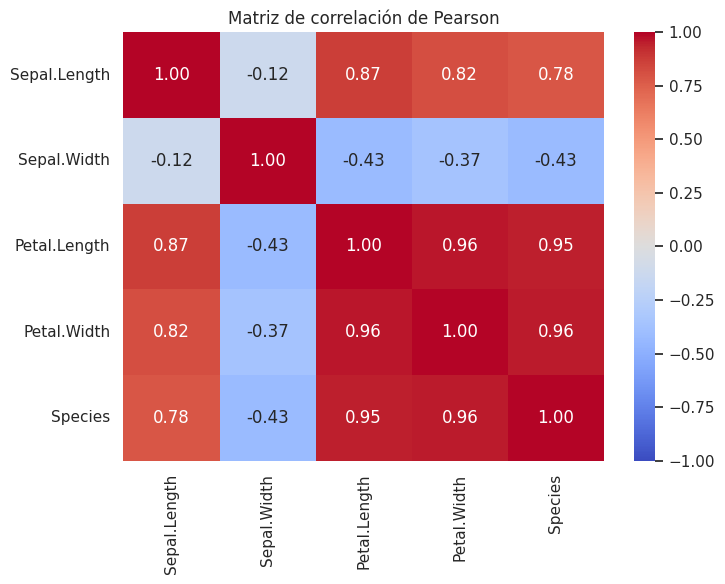

In [15]:
plt.figure(figsize=(7.5, 6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.savefig(FIG / "correlacion_pearson.png", dpi=160)
plt.show()

In [16]:
def calculate_pvalues(df):
    df = df.dropna()._get_numeric_data()
    df_cols = df.columns
    pvalues = pd.DataFrame(np.ones((len(df_cols), len(df_cols))),
                           columns=df_cols, index=df_cols)
    for col1 in df_cols:
        for col2 in df_cols:
            if col1 == col2:
                pvalues.loc[col1, col2] = 0.0
            else:
                _, p = pearsonr(df[col1], df[col2])
                pvalues.loc[col1, col2] = p
    return pvalues


pvalue_matrix = calculate_pvalues(bbdd2)
pvalue_matrix.to_csv(OUT / "matriz_pvalores.csv")
pvalue_matrix.map(lambda x: f"{x:.3e}")

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
Sepal.Length,0.000e+00,1.519e-01,1.039e-47,2.325e-37,2.890e-32
Sepal.Width,1.519e-01,0.000e+00,4.513e-08,4.073e-06,5.202e-08
Petal.Length,1.039e-47,4.513e-08,0.000e+00,4.675e-86,4.202e-76
Petal.Width,2.325e-37,4.073e-06,4.675e-86,0.000e+00,4.155e-81
Species,2.890e-32,5.202e-08,4.202e-76,4.155e-81,0.000e+00


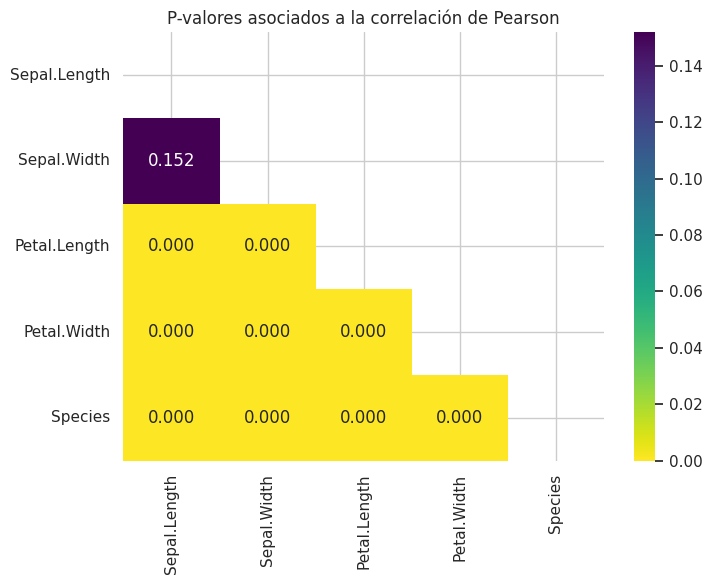

In [17]:
plt.figure(figsize=(7.5, 6))
sns.heatmap(pvalue_matrix, annot=True, cmap="viridis_r", fmt=".3f",
            mask=np.triu(np.ones_like(pvalue_matrix, dtype=bool)))
plt.title("P-valores asociados a la correlación de Pearson")
plt.tight_layout()
plt.savefig(FIG / "pvalores_pearson.png", dpi=160)
plt.show()

## 9. Normalización de las variables de entrada

In [18]:
bbdd = bbdd2.iloc[:, 0:4]

scaler = MinMaxScaler()
bbdd_norm = pd.DataFrame(scaler.fit_transform(bbdd), columns=bbdd.columns)

Species = bbdd1[["Species"]]
bbdd_norm_completa = pd.concat([bbdd_norm, Species], axis=1)
bbdd_norm_completa.to_csv(OUT / "base_normalizada.csv", index=False)

print("Base de datos normalizada completa:")
print(bbdd_norm_completa.head())
print("\nRangos tras la normalización:")
print(bbdd_norm_completa[COLUMNAS].agg(["min", "max"]).round(3))

Base de datos normalizada completa:
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0      0.222222     0.625000      0.067797     0.041667  Setosa
1      0.166667     0.416667      0.067797     0.041667  Setosa
2      0.111111     0.500000      0.050847     0.041667  Setosa
3      0.083333     0.458333      0.084746     0.041667  Setosa
4      0.194444     0.666667      0.067797     0.041667  Setosa

Rangos tras la normalización:
     Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
min           0.0          0.0           0.0          0.0
max           1.0          1.0           1.0          1.0


## 10. Selección del modelo base: por qué la exactitud no basta

Un certificador con opción de rechazo necesita algo que un clasificador convencional no requiere:
una estimación de confianza suficientemente graduada para ordenar las observaciones de más a menos
dudosas. Un modelo que solo produzca unos pocos valores de confianza distintos no permite fijar un
umbral con precisión, por muy exacto que sea.

Se comparan tres candidatos usando validación cruzada de cinco pliegues sobre las 150 observaciones.

In [19]:
X = bbdd1[COLUMNAS]
y = bbdd1["Species"].astype(str)
cv = StratifiedKFold(5, shuffle=True, random_state=42)

candidatos = {
    "Regresión logística": LogisticRegression(max_iter=1000),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Árbol de decisión (prof. 3)": DecisionTreeClassifier(max_depth=3, random_state=42),
}

filas = []
for nombre, estimador in candidatos.items():
    pipe = make_pipeline(MinMaxScaler(), estimador)
    pr = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")
    clases_ord = np.array(sorted(y.unique()))
    pred_c = clases_ord[pr.argmax(1)]
    filas.append({
        "Modelo": nombre,
        "Exactitud (CV)": round(accuracy_score(y, pred_c), 3),
        "Valores de confianza distintos": len(np.unique(np.round(pr.max(1), 4))),
    })

comparacion = pd.DataFrame(filas)
comparacion.to_csv(OUT / "comparacion_modelos.csv", index=False)
comparacion

,Modelo,Exactitud (CV),Valores de confianza distintos
0,Regresión logística,0.927,147
1,k-NN (k=5),0.960,3
2,Árbol de decisión (prof. 3),0.967,7


El resultado invierte el criterio habitual de selección. El árbol de decisión y k-NN son más exactos,
pero producen apenas 7 y 3 valores de confianza distintos respectivamente: sus probabilidades son
proporciones de hojas o de vecinos, y no permiten discriminar entre un lote dudoso y uno claro. La
regresión logística es algo menos exacta y aun así genera 147 valores distintos sobre 150
observaciones, lo que la convierte en la única capaz de sostener un umbral de abstención.

Se adopta la regresión logística como modelo base. La decisión responde al mecanismo que el caso
exige, no a la métrica de desempeño.

## 11. Verificación del certificador con opción de rechazo

Las probabilidades se obtienen con `cross_val_predict`, de modo que cada observación recibe una
estimación calculada por un modelo que no la vio durante su entrenamiento. Esto entrega 150
predicciones fuera de muestra en lugar de las 30 de una partición única, lo que hace mucho más
estable la curva que se construye a continuación.

In [20]:
modelo = make_pipeline(MinMaxScaler(), LogisticRegression(max_iter=1000))
proba = cross_val_predict(modelo, X, y, cv=cv, method="predict_proba")

clases = np.array(sorted(y.unique()))
prediccion = clases[proba.argmax(1)]
confianza = proba.max(1)
acierto = prediccion == y.values

print("Exactitud sin abstención:", round(acierto.mean(), 3))
print("Errores totales:", int((~acierto).sum()))
print()
print(pd.DataFrame(confusion_matrix(y, prediccion, labels=list(clases)),
                   index=[f"Real {c}" for c in clases],
                   columns=[f"Pred {c}" for c in clases]))

Exactitud sin abstención: 0.927
Errores totales: 11

                 Pred Setosa  Pred Versicolor  Pred Virginica
Real Setosa               50                0               0
Real Versicolor            0               43               7
Real Virginica             0                4              46


Los 11 errores del clasificador sin abstención se producen íntegramente entre *Versicolor* y
*Virginica*. Ni un solo lote de *Setosa* se confunde, exactamente como anticipaba el apartado 7.

In [21]:
# ¿Es la confianza un buen indicador de dónde está la dificultad?
resumen_conf = pd.DataFrame({"Species": y.values, "Confianza": confianza}) \
    .groupby("Species")["Confianza"].agg(["mean", "min"]).round(3)
resumen_conf.columns = ["Confianza media", "Confianza mínima"]
resumen_conf

,Confianza media,Confianza mínima
Species,,
Setosa,0.860,0.673
Versicolor,0.581,0.462
Virginica,0.696,0.501


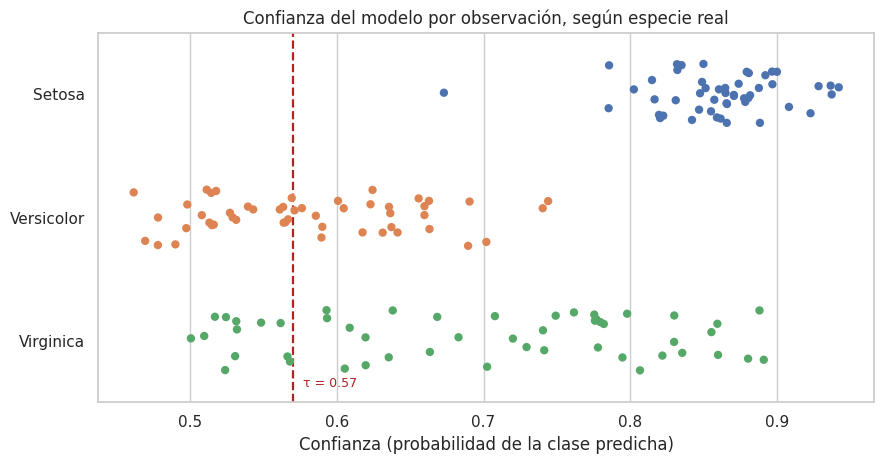

In [22]:
plt.figure(figsize=(9, 4.8))
tmp = pd.DataFrame({"Species": y.values, "Confianza": confianza})
sns.stripplot(data=tmp, x="Confianza", y="Species", hue="Species",
              palette="deep", jitter=.25, s=6, legend=False)
plt.axvline(0.57, color=ROJO, ls="--", lw=1.6)
plt.text(0.577, 2.38, "τ = 0.57", color=ROJO, fontsize=9)
plt.title("Confianza del modelo por observación, según especie real")
plt.xlabel("Confianza (probabilidad de la clase predicha)"); plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG / "confianza_por_especie.png", dpi=160)
plt.show()

### 11.1 Curva de cobertura frente a exactitud selectiva

Se define la regla de decisión: si la confianza alcanza el umbral τ, el lote se certifica de forma
automática; si no lo alcanza, se deriva al especialista. Dos indicadores describen el
comportamiento del sistema en función de τ:

- **Cobertura:** proporción de lotes que el certificador resuelve sin intervención humana.
- **Exactitud selectiva:** exactitud calculada únicamente sobre los lotes certificados.

Subir τ mejora la exactitud selectiva y reduce la cobertura. El compromiso entre ambos es la
decisión de diseño central del caso.

In [23]:
umbrales = np.round(np.arange(0.34, 0.941, 0.01), 2)

filas = []
for t in umbrales:
    aceptado = confianza >= t
    n_ac = int(aceptado.sum())
    filas.append({
        "Umbral": float(t),
        "Cobertura": round(n_ac / len(y), 3),
        "Lotes certificados": n_ac,
        "Exactitud selectiva": round(float(acierto[aceptado].mean()), 4) if n_ac else np.nan,
        "Errores certificados": int((~acierto[aceptado]).sum()),
        "Derivados a revisión": int(len(y) - n_ac),
    })

curva = pd.DataFrame(filas)
curva.to_csv(OUT / "curva_cobertura_exactitud.csv", index=False)
curva[curva["Umbral"].isin([0.34, 0.50, 0.57, 0.60, 0.64, 0.70, 0.80, 0.90])]

,Umbral,Cobertura,Lotes certificados,Exactitud selectiva,Errores certificados,Derivados a revisión
0,0.34,1.000,150,0.9267,11,0
16,0.50,0.953,143,0.9441,8,7
23,0.57,0.753,113,0.9823,2,37
26,0.60,0.707,106,0.9811,2,44
30,0.64,0.607,91,1.0000,0,59
36,0.70,0.527,79,1.0000,0,71
46,0.80,0.387,58,1.0000,0,92
56,0.90,0.040,6,1.0000,0,144


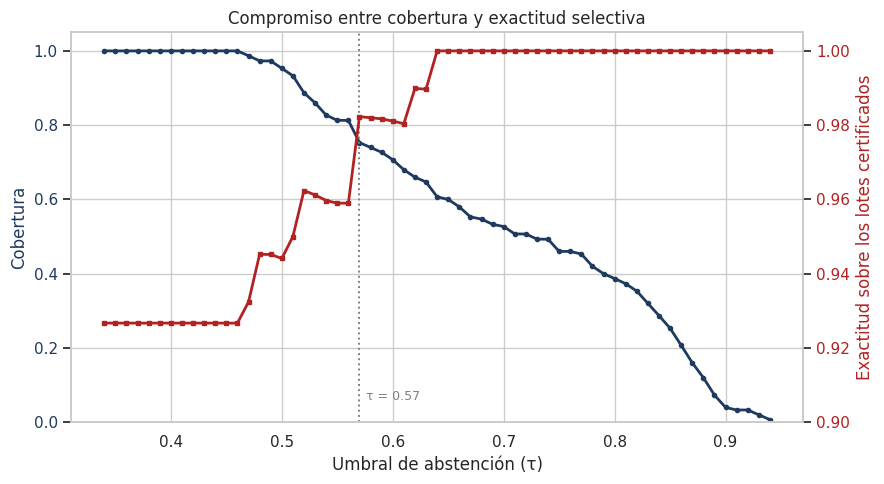

In [24]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(curva["Umbral"], curva["Cobertura"], color=AZUL, lw=2, marker="o", ms=3)
ax1.set_xlabel("Umbral de abstención (τ)")
ax1.set_ylabel("Cobertura", color=AZUL)
ax1.tick_params(axis="y", labelcolor=AZUL); ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(curva["Umbral"], curva["Exactitud selectiva"], color=ROJO, lw=2, marker="s", ms=3)
ax2.set_ylabel("Exactitud sobre los lotes certificados", color=ROJO)
ax2.tick_params(axis="y", labelcolor=ROJO); ax2.set_ylim(0.9, 1.005); ax2.grid(False)

ax1.axvline(0.57, color="gray", ls=":", lw=1.4)
ax1.text(0.576, 0.06, "τ = 0.57", color="gray", fontsize=9)
plt.title("Compromiso entre cobertura y exactitud selectiva")
fig.tight_layout()
plt.savefig(FIG / "curva_cobertura_exactitud.png", dpi=160)
plt.show()

### 11.2 Umbral que minimiza el costo esperado

La curva anterior describe el compromiso pero no elige un punto. Para elegirlo se necesita el dato
que el negocio aporta: cuánto cuesta certificar mal un lote en relación con lo que cuesta revisarlo
manualmente. El costo esperado se expresa como

```
Costo(τ) = c_error × (errores entre los certificados) + c_revisión × (lotes derivados)
```

Como la razón real no está disponible en esta fase, se evalúan varios escenarios para determinar qué
tan sensible es la decisión a ese parámetro.

In [25]:
def costo_esperado(t, c_error, c_revision=1):
    aceptado = confianza >= t
    return c_error * int((~acierto[aceptado]).sum()) + c_revision * int((~aceptado).sum())


filas = []
for razon in [3, 5, 10, 20, 50]:
    costos = [(float(t), costo_esperado(t, razon)) for t in umbrales]
    t_opt, c_opt = min(costos, key=lambda z: z[1])
    aceptado = confianza >= t_opt
    filas.append({
        "Razón costo error : revisión": f"{razon}:1",
        "Umbral óptimo": t_opt,
        "Cobertura": round(float(aceptado.mean()), 3),
        "Errores certificados": int((~acierto[aceptado]).sum()),
        "Derivados a revisión": int((~aceptado).sum()),
        "Costo esperado": c_opt,
    })

optimos = pd.DataFrame(filas)
optimos.to_csv(OUT / "optimo_costo_esperado.csv", index=False)
optimos

,Razón costo error : revisión,Umbral óptimo,Cobertura,Errores certificados,Derivados a revisión,Costo esperado
0,3:1,0.48,0.973,8,4,28
1,5:1,0.52,0.887,5,17,42
2,10:1,0.57,0.753,2,37,57
3,20:1,0.64,0.607,0,59,59
4,50:1,0.64,0.607,0,59,59


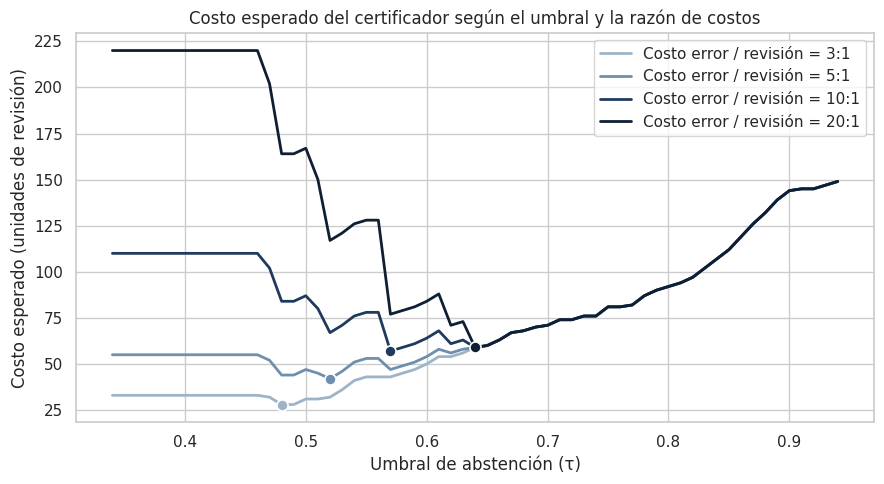

In [26]:
plt.figure(figsize=(9, 5))
for razon, color in zip([3, 5, 10, 20], ["#9DB4C8", "#6E8FAE", AZUL, "#0E1F33"]):
    costos = [costo_esperado(t, razon) for t in umbrales]
    plt.plot(umbrales, costos, lw=2, color=color, label=f"Costo error / revisión = {razon}:1")
    i = int(np.argmin(costos))
    plt.plot([umbrales[i]], [costos[i]], "o", color=color, ms=8, mec="white", mew=1.2)

plt.xlabel("Umbral de abstención (τ)")
plt.ylabel("Costo esperado (unidades de revisión)")
plt.title("Costo esperado del certificador según el umbral y la razón de costos")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "costo_esperado.png", dpi=160)
plt.show()

La decisión resulta ser sensible a la razón de costos, y esa sensibilidad es informativa. Si revisar
cuesta relativamente poco frente a equivocarse, conviene un umbral alto y derivar más; si la revisión
es cara, conviene aceptar algún error a cambio de cobertura. A partir de una razón de 20:1 el óptimo
se estabiliza en τ = 0,64, el punto donde el certificador deja de cometer errores.

Para el desarrollo posterior se adopta τ = 0,57, correspondiente a un escenario de 10:1, con la
advertencia explícita de que este valor es provisional y su fijación definitiva requiere la
estimación de costos reales por parte de la unidad de certificación.

### 11.3 Comportamiento del certificador en el punto de operación

In [27]:
TAU = 0.57
aceptado = confianza >= TAU

print(f"Umbral de abstención τ = {TAU}")
print(f"Lotes certificados automáticamente : {int(aceptado.sum())} ({aceptado.mean():.1%})")
print(f"Lotes derivados a revisión         : {int((~aceptado).sum())} ({(~aceptado).mean():.1%})")
print(f"Exactitud selectiva                : {acierto[aceptado].mean():.4f}")
print(f"Errores entre los certificados     : {int((~acierto[aceptado]).sum())}")
print(f"Errores capturados por la abstención: {int((~acierto[~aceptado]).sum())} de {int((~acierto).sum())}")

Umbral de abstención τ = 0.57
Lotes certificados automáticamente : 113 (75.3%)
Lotes derivados a revisión         : 37 (24.7%)
Exactitud selectiva                : 0.9823
Errores entre los certificados     : 2
Errores capturados por la abstención: 9 de 11


In [28]:
# ¿A qué especies pertenecen los lotes derivados?
derivados = pd.Series(y.values[~aceptado]).value_counts().reindex(clases, fill_value=0)
derivados.name = "Lotes derivados a revisión"
derivados.to_frame()

,Lotes derivados a revisión
Setosa,0
Versicolor,25
Virginica,12


Este es el resultado central del proyecto. De los 37 lotes que el certificador deriva a
revisión, **ninguno es Setosa**: 25 son *Versicolor* y 12 son *Virginica*. El mecanismo de abstención
identifica por sí solo la región donde se concentra la dificultad, sin que se le haya indicado dónde
buscarla. La regla de derivación reproduce, a partir de la confianza del modelo, la misma estructura
que el análisis exploratorio había detectado en los datos.

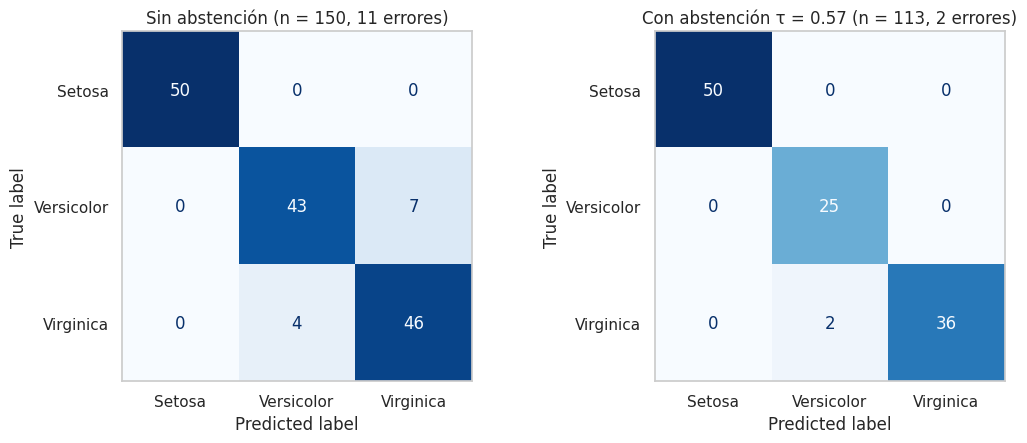

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ConfusionMatrixDisplay(confusion_matrix(y, prediccion, labels=list(clases)),
                       display_labels=clases).plot(cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title("Sin abstención (n = 150, 11 errores)")
ConfusionMatrixDisplay(confusion_matrix(y.values[aceptado], prediccion[aceptado], labels=list(clases)),
                       display_labels=clases).plot(cmap="Blues", colorbar=False, ax=axes[1])
axes[1].set_title(f"Con abstención τ = {TAU} (n = {int(aceptado.sum())}, 2 errores)")
for a in axes:
    a.grid(False)
plt.tight_layout()
plt.savefig(FIG / "matrices_confusion.png", dpi=160)
plt.show()

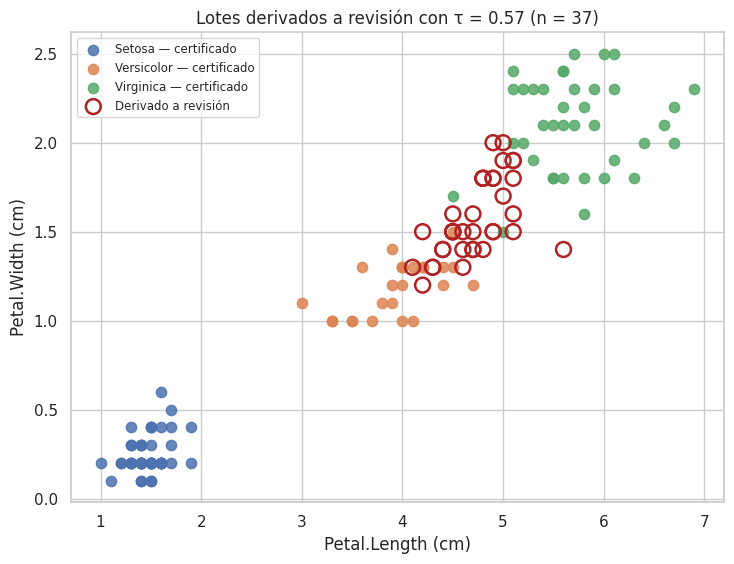

In [30]:
plt.figure(figsize=(7.5, 5.8))
for especie in clases:
    m = (y.values == especie) & aceptado
    plt.scatter(bbdd1.loc[m, "Petal.Length"], bbdd1.loc[m, "Petal.Width"],
                s=55, label=f"{especie} — certificado", alpha=.85)

m = ~aceptado
plt.scatter(bbdd1.loc[m, "Petal.Length"], bbdd1.loc[m, "Petal.Width"], s=115,
            facecolors="none", edgecolors=ROJO, linewidths=1.8, label="Derivado a revisión")

plt.legend(fontsize=8.5, loc="upper left")
plt.title(f"Lotes derivados a revisión con τ = {TAU} (n = {int((~aceptado).sum())})")
plt.xlabel("Petal.Length (cm)"); plt.ylabel("Petal.Width (cm)")
plt.tight_layout()
plt.savefig(FIG / "zona_abstencion.png", dpi=160)
plt.show()

## 12. Aplicación a lotes entrantes

Se aplica el certificador a cuatro lotes simulados que representan los casos previstos en la
recepción: dos resolubles y dos ubicados en la franja de solapamiento.

In [31]:
lotes = pd.DataFrame(
    [[5.0, 3.4, 1.5, 0.2],
     [6.9, 3.1, 5.6, 2.2],
     [6.1, 2.9, 4.8, 1.7],
     [6.0, 2.7, 5.1, 1.6]],
    columns=COLUMNAS,
    index=["L-2041", "L-2042", "L-2043", "L-2044"],
)

certificador = make_pipeline(MinMaxScaler(), LogisticRegression(max_iter=1000)).fit(X, y)
probabilidades = certificador.predict_proba(lotes)

resultado = pd.DataFrame(probabilidades, columns=certificador.classes_, index=lotes.index).round(3)
resultado["Confianza"] = probabilidades.max(axis=1).round(3)
resultado["Decisión"] = [
    f"Certificar como {certificador.classes_[fila.argmax()]}" if fila.max() >= TAU
    else "Derivar a revisión"
    for fila in probabilidades
]
resultado = lotes.join(resultado)
resultado.to_csv(OUT / "decision_lotes.csv")
resultado

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Setosa,Versicolor,Virginica,Confianza,Decisión
L-2041,5.0,3.4,1.5,0.2,0.880,0.116,0.004,0.880,Certificar como Setosa
L-2042,6.9,3.1,5.6,2.2,0.006,0.192,0.802,0.802,Certificar como Virginica
L-2043,6.1,2.9,4.8,1.7,0.042,0.462,0.496,0.496,Derivar a revisión
L-2044,6.0,2.7,5.1,1.6,0.036,0.510,0.454,0.510,Derivar a revisión


Los dos primeros lotes superan el umbral y se certifican sin intervención. Los dos últimos quedan por
debajo —0,496 y 0,510— y se derivan al especialista. El caso L-2044 es especialmente ilustrativo: un
clasificador convencional lo habría etiquetado como *Versicolor* con una diferencia de apenas 56
milésimas sobre *Virginica*, y esa decisión habría quedado registrada como una certificación firme.
El certificador con opción de rechazo, en cambio, reconoce que la evidencia disponible no alcanza y
traslada la decisión a quien puede resolverla.

## 13. Correspondencia con el proceso KDD

| Etapa KDD | Qué se hizo en este cuaderno | Celdas |
|---|---|---|
| Selección | Carga desde `data/iris.csv` y verificación contra `load_iris()` | 3 |
| Preprocesamiento | Tipos de dato, faltantes, duplicados, balance y localización de la incertidumbre | 4, 5, 6, 7 |
| Transformación | Codificación de `Species` y normalización MinMax de las entradas | 8, 9 |
| Minería de datos | Selección del modelo base y verificación del mecanismo de abstención | 10, 11 |
| Interpretación | Lectura de la curva de cobertura, del costo esperado y de la composición de los derivados | 11, 12 |

Las tres primeras etapas se desarrollan por completo. La cuarta se aborda como verificación de
viabilidad, en coherencia con el alcance declarado para la Fase 1.

## 14. Síntesis

El conjunto reúne 150 lotes con medición completa, tres especies con 50 registros cada una y cuatro
variables numéricas continuas. Existe una variable de decisión observada y categórica, de modo que el
enfoque corresponde a aprendizaje supervisado de clasificación.

La contribución de esta fase está en el mecanismo de decisión. El análisis exploratorio mostró que la
incertidumbre del problema está localizada: *Setosa* se separa por un margen de 1,1 cm sobre una sola
variable, mientras que el par restante comparte hasta el 70 % del rango. Un clasificador convencional
responde con la misma firmeza en ambas regiones, y sus 11 errores se producen íntegramente en la
segunda.

Incorporar una opción de rechazo cambia el comportamiento del sistema. Con τ = 0,57 el certificador
resuelve automáticamente el 75,3 % de los lotes con una exactitud selectiva de 0,982, deriva 37 casos
a revisión y captura 9 de los 11 errores que habría cometido. Ninguno de los lotes derivados es
*Setosa*.

La Fase 2 deberá calibrar las probabilidades del modelo, dado que las estimaciones actuales ordenan
correctamente pero no representan frecuencias reales, y fijar el umbral definitivo a partir de los
costos que la unidad de certificación pueda estimar.